# Detección de Fraude en Transacciones — IEEE-CIS

Análisis exploratorio, feature engineering y modelado sobre `train_transaction.csv` (competencia IEEE-CIS Fraud Detection de Kaggle, Vesta Corporation). Alcance: solo la tabla de transacciones, sin unir la tabla de identidad.

In [1]:
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("..")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

DATA_PATH = "../dataset/ieee-cis/train_transaction.csv"

## Carga con optimización de dtypes

`train_transaction.csv` pesa ~2.2 GB en memoria con los dtypes por defecto de pandas (todo float64/int64/object). Bajamos precisión numérica y convertimos las categóricas conocidas a `category` para trabajar cómodo durante las iteraciones.

In [2]:
CATEGORICAL_COLS = [
    "ProductCD", "card4", "card6",
    "P_emaildomain", "R_emaildomain",
    "M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9",
    "addr1", "addr2", "card1", "card2", "card3", "card5",
]


def optimizar_tipos(df: pd.DataFrame) -> pd.DataFrame:
    columnas_float = df.select_dtypes(include="float64").columns
    df[columnas_float] = df[columnas_float].astype("float32")
    columnas_int = df.select_dtypes(include="int64").columns
    for col in columnas_int:
        df[col] = pd.to_numeric(df[col], downcast="integer")
    return df


df = pd.read_csv(DATA_PATH)
df = optimizar_tipos(df)
for col in CATEGORICAL_COLS:
    df[col] = df[col].astype("category")
df = df.copy()

print(f"Dimensiones: {df.shape}")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Dimensiones: (590540, 394)
Memoria: 0.90 GB


## 1. Distribución del target

Tasa de fraude: 3.4990%


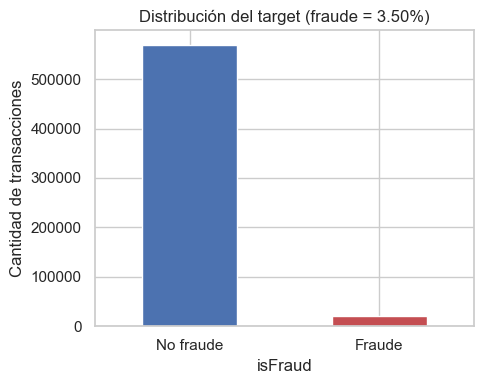

In [3]:
fraud_rate = df["isFraud"].mean()
print(f"Tasa de fraude: {fraud_rate:.4%}")

fig, ax = plt.subplots(figsize=(5, 4))
df["isFraud"].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["No fraude", "Fraude"], rotation=0)
ax.set_ylabel("Cantidad de transacciones")
ax.set_title(f"Distribución del target (fraude = {fraud_rate:.2%})")
plt.tight_layout()
plt.show()

## 2. ¿El monto diferencia al fraude?

`TransactionAmt` es el monto real de la transacción en USD. Comparamos su distribución entre transacciones legítimas y fraudulentas.

            count        mean         std    min        25%   50%    75%  \
isFraud                                                                    
0        569877.0  134.511658  239.398010  0.251  43.970001  68.5  120.0   
1         20663.0  149.244766  232.210709  0.292  35.043999  75.0  161.0   

                  max  
isFraud                
0        31937.390625  
1         5191.000000  


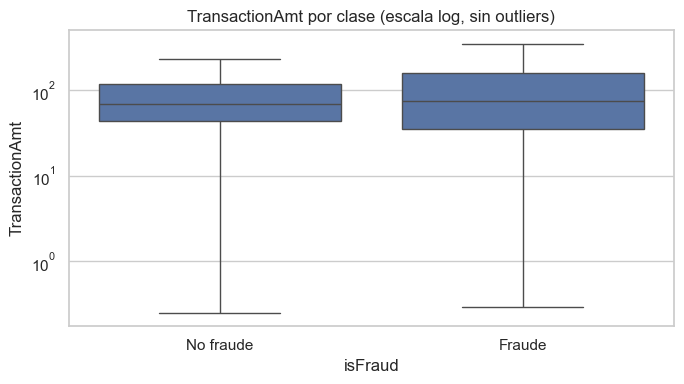

In [4]:
print(df.groupby("isFraud")["TransactionAmt"].describe())

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="isFraud", y="TransactionAmt", ax=ax, showfliers=False)
ax.set_yscale("log")
ax.set_xticks([0, 1], ["No fraude", "Fraude"])
ax.set_title("TransactionAmt por clase (escala log, sin outliers)")
plt.tight_layout()
plt.show()

## 3. Tasa de fraude por categoría

Si una categoría tiene una tasa de fraude muy distinta al promedio general (línea gris), la variable le aporta información al modelo.

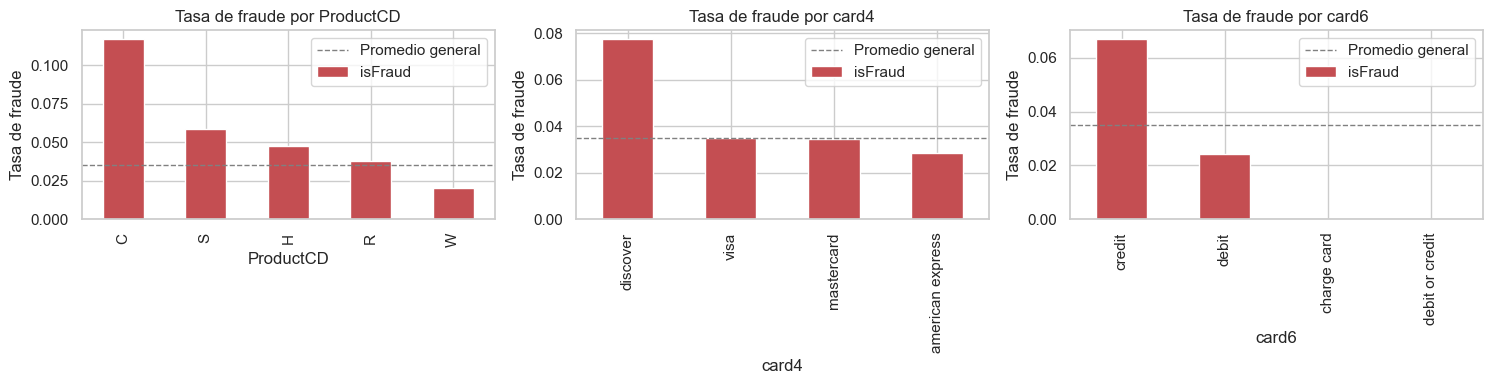

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["ProductCD", "card4", "card6"]):
    tasa = df.groupby(col, observed=True)["isFraud"].mean().sort_values(ascending=False)
    tasa.plot(kind="bar", ax=ax, color="#C44E52")
    ax.axhline(fraud_rate, color="gray", linestyle="--", linewidth=1, label="Promedio general")
    ax.set_title(f"Tasa de fraude por {col}")
    ax.set_ylabel("Tasa de fraude")
    ax.legend()
plt.tight_layout()
plt.show()

## 4. Valores faltantes

174 columnas tienen más del 50% de nulos. Antes de decidir qué hacer con ellas, miramos si el hecho de que falte el dato se relaciona con el fraude: calculamos la correlación entre una columna 0/1 ("falta el dato") e `isFraud`.

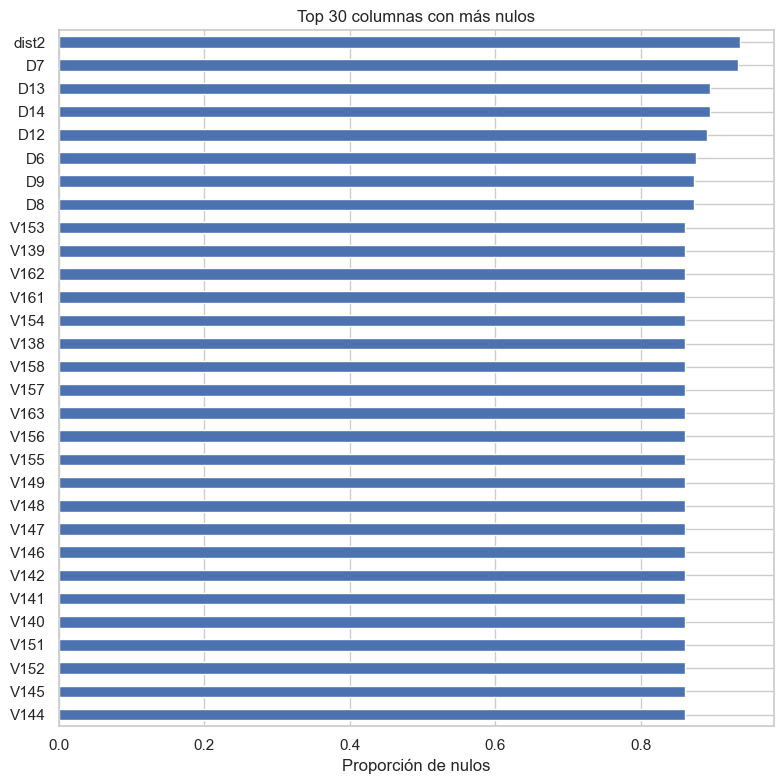

Top 15 columnas donde 'falta el dato' se relaciona con fraude:
D7              -0.164478
D12             -0.157344
D14             -0.151227
D6              -0.144233
D9              -0.144123
D8              -0.144123
D13             -0.140420
R_emaildomain   -0.140127
V169            -0.133923
V200            -0.133923
V201            -0.133923
V180            -0.133923
V208            -0.133923
V185            -0.133923
V171            -0.133923
dtype: float64


In [6]:
missing_rate = df.isnull().mean().sort_values(ascending=False)
top_missing = missing_rate.head(30)

fig, ax = plt.subplots(figsize=(8, 8))
top_missing.plot(kind="barh", ax=ax, color="#4C72B0")
ax.invert_yaxis()
ax.set_xlabel("Proporción de nulos")
ax.set_title("Top 30 columnas con más nulos")
plt.tight_layout()
plt.show()

senial_missingness = {}
for col in missing_rate[missing_rate > 0.5].index:
    es_nulo = df[col].isnull().astype(int)
    senial_missingness[col] = np.corrcoef(es_nulo, df["isFraud"])[0, 1]

serie_senial = pd.Series(senial_missingness).sort_values(key=abs, ascending=False)
print("Top 15 columnas donde 'falta el dato' se relaciona con fraude:")
print(serie_senial.head(15))

## 5. Patrón temporal

`TransactionDT` no es una fecha real sino segundos desde un punto de referencia. Igual sirve para derivar la hora del día y el día relativo, que usamos para ver patrones y para separar los datos en el tiempo.

Rango temporal: 1 a 182 días


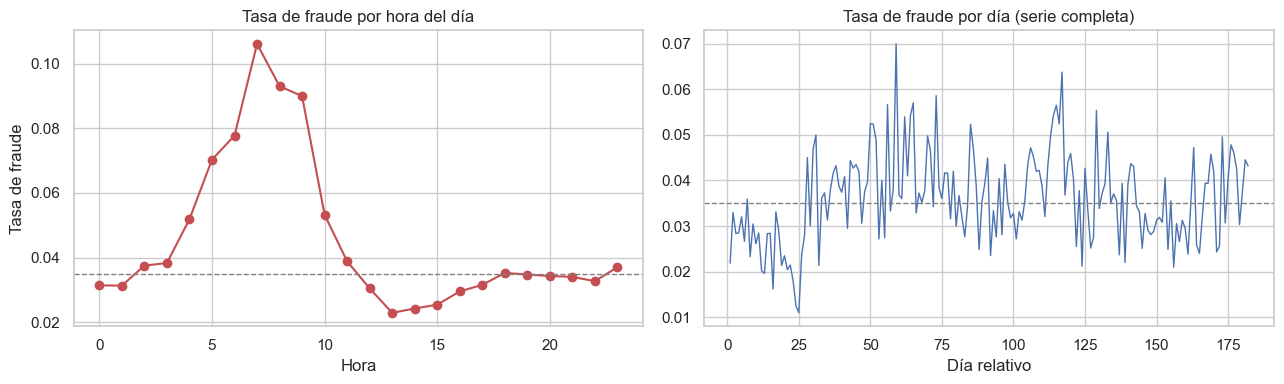

In [7]:
SEGUNDOS_POR_DIA = 24 * 60 * 60
df["dia_relativo"] = df["TransactionDT"] // SEGUNDOS_POR_DIA
df["hora_del_dia"] = (df["TransactionDT"] // 3600) % 24

print(f"Rango temporal: {df['dia_relativo'].min():.0f} a {df['dia_relativo'].max():.0f} días")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

por_hora = df.groupby("hora_del_dia")["isFraud"].mean()
por_hora.plot(ax=axes[0], marker="o", color="#C44E52")
axes[0].set_title("Tasa de fraude por hora del día")
axes[0].set_xlabel("Hora")
axes[0].set_ylabel("Tasa de fraude")
axes[0].axhline(fraud_rate, color="gray", linestyle="--", linewidth=1)

por_dia = df.groupby("dia_relativo")["isFraud"].mean()
por_dia.plot(ax=axes[1], color="#4C72B0", linewidth=1)
axes[1].set_title("Tasa de fraude por día (serie completa)")
axes[1].set_xlabel("Día relativo")
axes[1].axhline(fraud_rate, color="gray", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

## 6. Preprocesamiento: `ColumnTransformer` + `Pipeline`

Definimos los cortes temporales (sección 7) antes del preprocesamiento, porque cualquier decisión que use el target tiene que tomarse solo con los datos de entrenamiento.

El `ColumnTransformer` aplica una transformación distinta a cada grupo de columnas:

| Grupo | Transformación | Por qué |
|---|---|---|
| Categóricas (`ProductCD`, `card4`, `M1`...) | `OrdinalEncoder` | LightGBM necesita números; las categorías nuevas se codifican como -1 |
| `TransactionDT` | `FunctionTransformer` → hora del día | El timestamp absoluto no sirve para predecir, la hora sí |
| Columnas donde la falta del dato se relaciona con el fraude | `MissingIndicator` | Columna 0/1 "falta el dato" (\|correlación\| > 0.10, calculada solo en train) |
| Resto de numéricas | sin cambios | LightGBM maneja los nulos por su cuenta |

Las funciones auxiliares están en `fraude_utils.py`: así el modelo guardado se puede cargar desde la app de Streamlit.

No usamos SMOTE ni pesos de clase: con 3.5% de fraude, LightGBM funcionó mejor sobre la distribución natural (ver sección 8).

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import MissingIndicator
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OrdinalEncoder

from fraude_utils import a_texto, extraer_hora, nombre_hora

corte_val = df["dia_relativo"].quantile(0.70)
corte_test = df["dia_relativo"].quantile(0.85)
es_train = df["dia_relativo"] <= corte_val
es_val = (df["dia_relativo"] > corte_val) & (df["dia_relativo"] <= corte_test)
es_test = df["dia_relativo"] > corte_test

UMBRAL_CORR_MISSING = 0.10
df_train = df.loc[es_train]
columnas_muy_nulas = missing_rate[missing_rate > 0.5].index
senial_train = pd.Series({
    col: np.corrcoef(df_train[col].isnull().astype(int), df_train["isFraud"])[0, 1]
    for col in columnas_muy_nulas
})
cols_missing_signal = senial_train[senial_train.abs() > UMBRAL_CORR_MISSING].index.tolist()
print(f"Columnas con señal de nulos en train (|r| > {UMBRAL_CORR_MISSING}): {len(cols_missing_signal)}")

COLUMNAS_ENTRADA = [
    c for c in df.columns if c not in ["TransactionID", "isFraud", "dia_relativo", "hora_del_dia"]
]
columnas_numericas = [
    c for c in COLUMNAS_ENTRADA if c not in CATEGORICAL_COLS and c != "TransactionDT"
]

codificador_categoricas = Pipeline([
    ("a_texto", FunctionTransformer(a_texto, feature_names_out="one-to-one")),
    ("codificar", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocesador = ColumnTransformer(
    transformers=[
        ("categoricas", codificador_categoricas, CATEGORICAL_COLS),
        ("hora", FunctionTransformer(extraer_hora, feature_names_out=nombre_hora), ["TransactionDT"]),
        ("flags_nulos", MissingIndicator(features="all"), cols_missing_signal),
        ("numericas", "passthrough", columnas_numericas),
    ],
    verbose_feature_names_out=False,
)
preprocesador.set_output(transform="pandas")

print(f"Columnas de entrada: {len(COLUMNAS_ENTRADA)}")
preprocesador

Columnas con señal de nulos en train (|r| > 0.1): 120
Columnas de entrada: 392


ColumnTransformer(transformers=[('categoricas',
                                 Pipeline(steps=[('a_texto',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<function a_texto at 0x7005dc6e80>)),
                                                 ('codificar',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['ProductCD', 'card4', 'card6',
                                  'P_emaildomain', 'R_emaildomain', 'M1', 'M2',
                                  'M3', 'M4', 'M5', 'M6', 'M7', 'M8', '...
                                  'V247', 'V246', 'V244', 'V243', 'V242',
                                  'V241', 'V237', 'V236', 'V233', 'V254',
                                  'V232', 'V231', 'V230', 'V229', 'V228',
                                  'V217', 'V226', 'V225', ...]),
                                ('numericas', 'passthrough',
                                 ['TransactionAmt', 'dist1', 'dist2', 'C1',
                                  'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8',
                                  'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1',
                                  'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8',
                                  'D9', 'D10', 'D11', 'D12', 'D13', ...])],
                  verbose_feature_names_out=False)

## 7. Split temporal: train / validación / test

Es la misma idea del backtesting de series temporales: entrenar con el pasado y evaluar con el futuro, que es como se usa el modelo en la realidad. Un split aleatorio mezclaría transacciones de un mismo cliente entre train y test, y daría métricas infladas.

- **Train**: 70% de días más antiguos.
- **Validación**: 15% siguiente, para el early stopping y para elegir el umbral.
- **Test**: 15% más reciente, se usa una sola vez para reportar las métricas.

In [9]:
X_train, y_train = df.loc[es_train, COLUMNAS_ENTRADA], df.loc[es_train, "isFraud"]
X_val, y_val = df.loc[es_val, COLUMNAS_ENTRADA], df.loc[es_val, "isFraud"]
X_test, y_test = df.loc[es_test, COLUMNAS_ENTRADA], df.loc[es_test, "isFraud"]

print(f"Cortes: día {corte_val:.0f} y día {corte_test:.0f} (de {df['dia_relativo'].max():.0f})")
print(f"Train: {X_train.shape}, tasa de fraude {y_train.mean():.3%}")
print(f"Val:   {X_val.shape}, tasa de fraude {y_val.mean():.3%}")
print(f"Test:  {X_test.shape}, tasa de fraude {y_test.mean():.3%}")

Cortes: día 120 y día 152 (de 182)
Train: (414542, 392), tasa de fraude 3.522%
Val:   (90568, 392), tasa de fraude 3.389%
Test:  (85430, 392), tasa de fraude 3.505%


## 8. Modelo: `Pipeline` con LightGBM

El `Pipeline` encadena el preprocesamiento y el modelo en un solo objeto: recibe una transacción cruda (tal como viene en el CSV) y devuelve la probabilidad de fraude. Eso es lo que guardamos en `model.pkl`.

LightGBM es gradient boosting sobre árboles: maneja nulos por su cuenta y suele rendir muy bien en datos tabulares. Usamos early stopping sobre validación.

Probamos compensar el desbalance con pesos de clase (`is_unbalance=True`) y el resultado empeoró en validación (AUC ~0.84 contra ~0.91 sin pesos): las probabilidades quedaban comprimidas y el entrenamiento se cortaba en la primera iteración. Por eso entrenamos sobre la distribución natural.

In [10]:
import lightgbm as lgb

pipeline = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", lgb.LGBMClassifier(
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )),
])

# El early stopping evalúa sobre validación ya preprocesada con el mismo preprocesador ajustado en train
X_val_procesado = preprocesador.fit(X_train).transform(X_val)

pipeline.fit(
    X_train, y_train,
    modelo__eval_set=[(X_val_procesado, y_val)],
    modelo__eval_metric="auc",
    modelo__categorical_feature=CATEGORICAL_COLS,
    modelo__callbacks=[lgb.early_stopping(stopping_rounds=80), lgb.log_evaluation(period=200)],
)

Training until validation scores don't improve for 80 rounds


[200]	valid_0's auc: 0.911416	valid_0's binary_logloss: 0.0869429


[400]	valid_0's auc: 0.918525	valid_0's binary_logloss: 0.0837888


[600]	valid_0's auc: 0.92042	valid_0's binary_logloss: 0.0829134


[800]	valid_0's auc: 0.921105	valid_0's binary_logloss: 0.0826777


Early stopping, best iteration is:
[751]	valid_0's auc: 0.921247	valid_0's binary_logloss: 0.0825848


Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('categoricas',
                                                  Pipeline(steps=[('a_texto',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<function a_texto at 0x7005dc6e80>)),
                                                                  ('codificar',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['ProductCD', 'card4',
                                                   'card6', 'P_emaildomain',
                                                   'R_emaildomain', 'M1',...
                                                  ['TransactionAmt', 'dist1',
                                                   'dist2', 'C1', 'C2', 'C3',
                                                   'C4', 'C5', 'C6', 'C7', 'C8',
                                                   'C9', 'C10', 'C11', 'C12',
                                                   'C13', 'C14', 'D1', 'D2',
                                                   'D3', 'D4', 'D5', 'D6', 'D7',
                                                   'D8', 'D9', 'D10', 'D11',
                                                   'D12', 'D13', ...])],
                                   verbose_feature_names_out=False)),
                ('modelo',
                 LGBMClassifier(colsample_bytree=0.8, learning_rate=0.03,
                                n_estimators=2000, n_jobs=-1, random_state=42,
                                subsample=0.8, verbosity=-1))])

## 9. Evaluación en test

Con 3.5% de fraude, la accuracy engaña: predecir siempre "no fraude" da 96.5%. Por eso usamos ROC-AUC, la curva precision-recall con su área (PR-AUC), y la matriz de confusión.

El umbral de decisión (0.5 por defecto) lo elegimos en validación buscando el máximo F1, y después lo aplicamos al test.

In [11]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, precision_recall_curve,
)

proba_val = pipeline.predict_proba(X_val)[:, 1]
precisiones_val, recalls_val, umbrales_val = precision_recall_curve(y_val, proba_val)
f1_val = 2 * precisiones_val * recalls_val / (precisiones_val + recalls_val + 1e-12)
mejor_umbral = umbrales_val[np.argmax(f1_val[:-1])]

proba_test = pipeline.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= mejor_umbral).astype(int)

auc = roc_auc_score(y_test, proba_test)
ap = average_precision_score(y_test, proba_test)
precisiones, recalls, _ = precision_recall_curve(y_test, proba_test)

print(f"Umbral elegido en validación (max F1): {mejor_umbral:.4f}")
print()
print("Métricas en TEST:")
print(f"ROC-AUC: {auc:.4f}")
print(f"PR-AUC (average precision): {ap:.4f}")
print()
print(classification_report(y_test, pred_test, target_names=["No fraude", "Fraude"]))

Umbral elegido en validación (max F1): 0.2864

Métricas en TEST:
ROC-AUC: 0.8917
PR-AUC (average precision): 0.5306

              precision    recall  f1-score   support

   No fraude       0.98      0.99      0.99     82436
      Fraude       0.66      0.44      0.53      2994

    accuracy                           0.97     85430
   macro avg       0.82      0.71      0.76     85430
weighted avg       0.97      0.97      0.97     85430



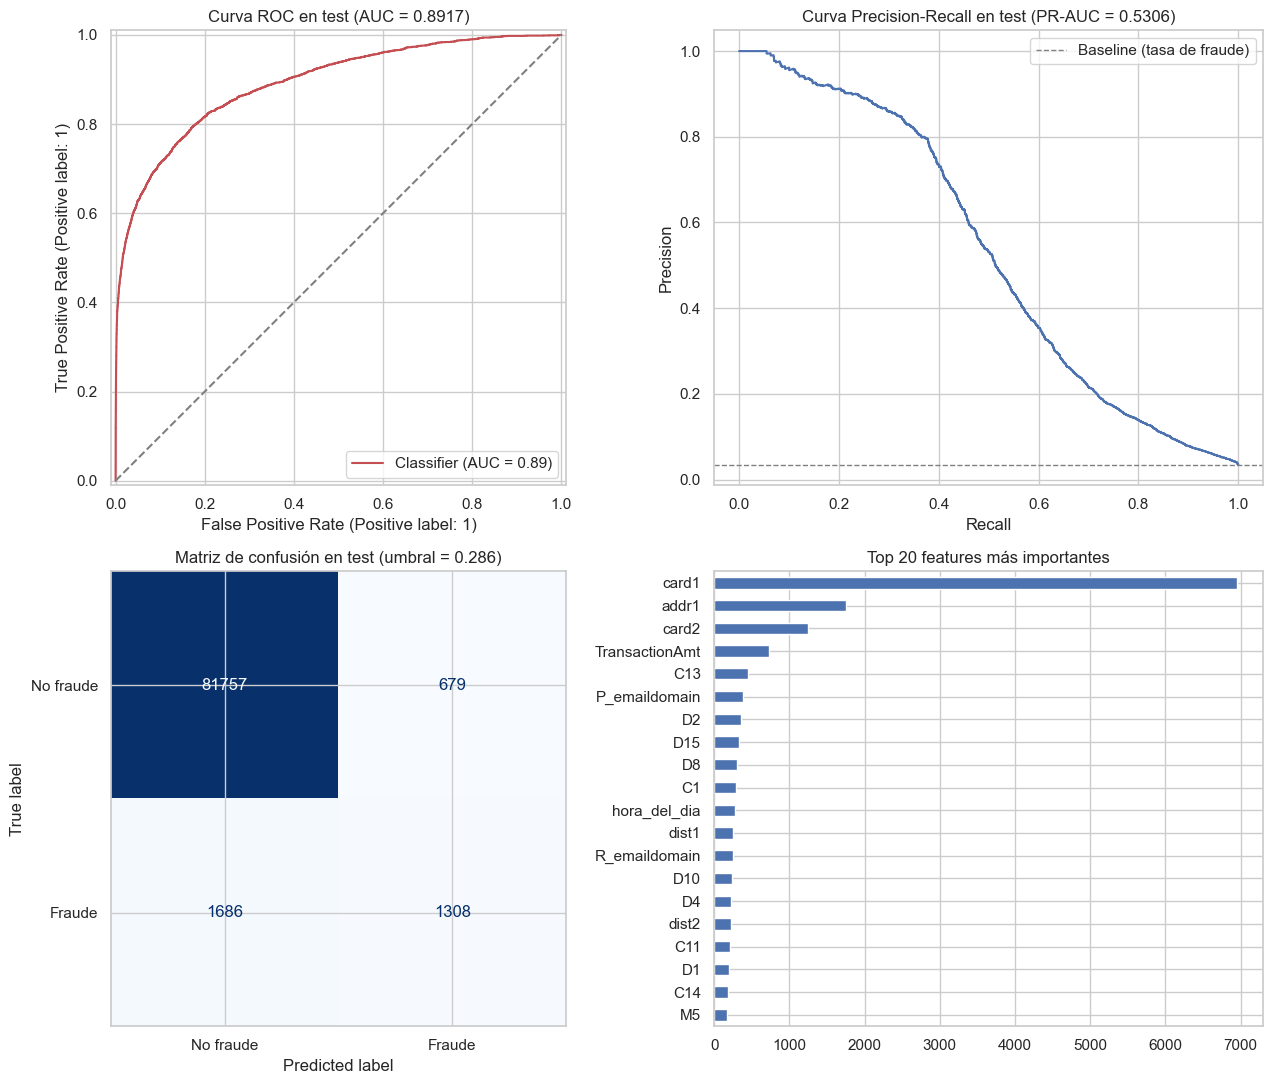

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))

RocCurveDisplay.from_predictions(y_test, proba_test, ax=axes[0, 0], color="#C44E52")
axes[0, 0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0, 0].set_title(f"Curva ROC en test (AUC = {auc:.4f})")

axes[0, 1].plot(recalls, precisiones, color="#4C72B0")
axes[0, 1].axhline(y_test.mean(), color="gray", linestyle="--", linewidth=1, label="Baseline (tasa de fraude)")
axes[0, 1].set_xlabel("Recall")
axes[0, 1].set_ylabel("Precision")
axes[0, 1].set_title(f"Curva Precision-Recall en test (PR-AUC = {ap:.4f})")
axes[0, 1].legend()

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_test, display_labels=["No fraude", "Fraude"], ax=axes[1, 0], colorbar=False, cmap="Blues"
)
axes[1, 0].set_title(f"Matriz de confusión en test (umbral = {mejor_umbral:.3f})")

importancias = pd.Series(
    pipeline.named_steps["modelo"].feature_importances_,
    index=preprocesador.get_feature_names_out(),
)
importancias = importancias.sort_values(ascending=False).head(20)
importancias.plot(kind="barh", ax=axes[1, 1], color="#4C72B0")
axes[1, 1].invert_yaxis()
axes[1, 1].set_title("Top 20 features más importantes")

plt.tight_layout()
plt.show()

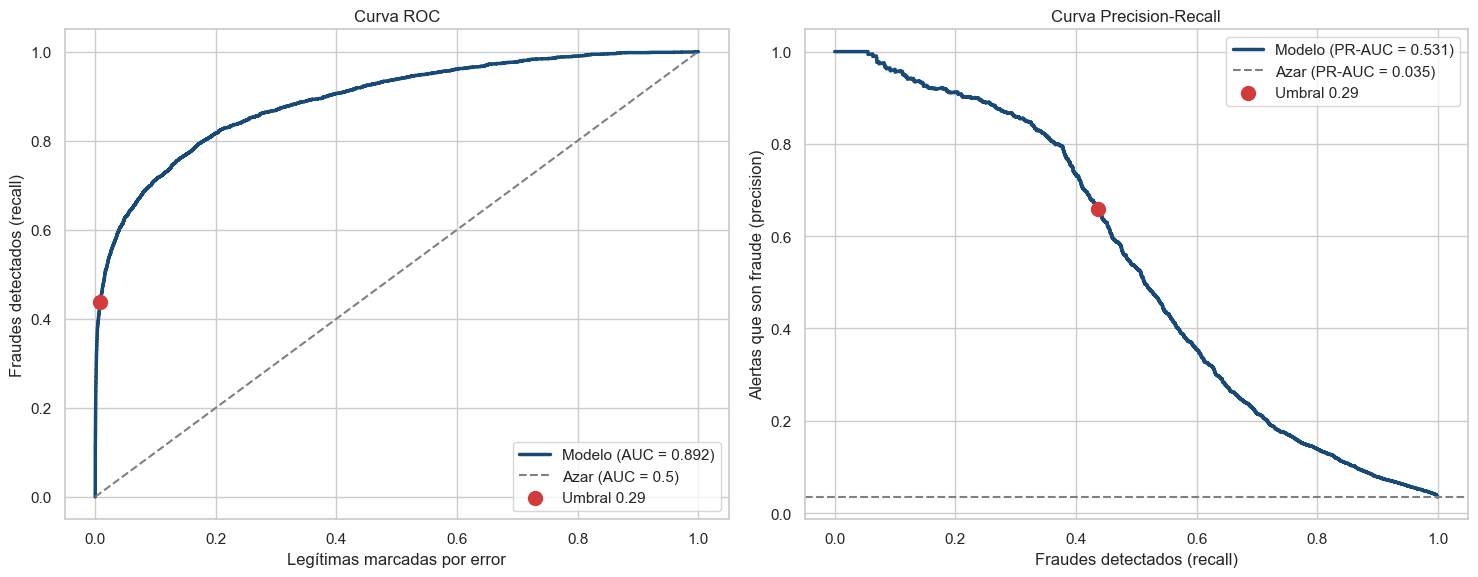

In [13]:
from pathlib import Path

from sklearn.metrics import roc_curve

CARPETA_FIGURAS = Path("../figuras")
CARPETA_FIGURAS.mkdir(exist_ok=True)

es_fraude_test = y_test.to_numpy() == 1
marcadas = pred_test == 1
tasa_fp_umbral = (marcadas & ~es_fraude_test).sum() / (~es_fraude_test).sum()
recall_umbral = (marcadas & es_fraude_test).sum() / es_fraude_test.sum()
precision_umbral = (marcadas & es_fraude_test).sum() / marcadas.sum()
tasas_fp, tasas_vp, _ = roc_curve(y_test, proba_test)

with plt.rc_context({"font.size": 14}):
    fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(15, 6))

    ax_roc.plot(tasas_fp, tasas_vp, color="#184a78", linewidth=2.5, label=f"Modelo (AUC = {auc:.3f})")
    ax_roc.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar (AUC = 0.5)")
    ax_roc.scatter(tasa_fp_umbral, recall_umbral, color="#d13b3b", s=100, zorder=3, label=f"Umbral {mejor_umbral:.2f}")
    ax_roc.set(title="Curva ROC", xlabel="Legítimas marcadas por error", ylabel="Fraudes detectados (recall)")
    ax_roc.legend(loc="lower right")

    ax_pr.plot(recalls, precisiones, color="#184a78", linewidth=2.5, label=f"Modelo (PR-AUC = {ap:.3f})")
    ax_pr.axhline(y_test.mean(), linestyle="--", color="gray", label=f"Azar (PR-AUC = {y_test.mean():.3f})")
    ax_pr.scatter(recall_umbral, precision_umbral, color="#d13b3b", s=100, zorder=3, label=f"Umbral {mejor_umbral:.2f}")
    ax_pr.set(title="Curva Precision-Recall", xlabel="Fraudes detectados (recall)", ylabel="Alertas que son fraude (precision)")
    ax_pr.legend(loc="upper right")

    plt.tight_layout()
    fig.savefig(CARPETA_FIGURAS / "curvas_test.png", dpi=200, bbox_inches="tight")
    plt.show()

## 10. Explicabilidad con SHAP

SHAP mide cuánto empuja cada variable la predicción de cada transacción hacia fraude (a la derecha) o hacia legítima (a la izquierda). Calculamos los valores con `TreeExplainer` sobre 2.000 transacciones de test.

Cómo leer el gráfico:

- Cada punto es una transacción; las variables están ordenadas de mayor a menor impacto.
- El color es el valor de la variable: rojo alto, azul bajo.
- En las categóricas (`card1`, `addr1`, `P_emaildomain`...) el color no tiene significado: son códigos del `OrdinalEncoder`, no cantidades.

Limitación: muchas variables importantes (`C*`, `D*`, `V*`) están anonimizadas por Vesta, así que SHAP dice cuáles pesan pero no siempre qué representan.

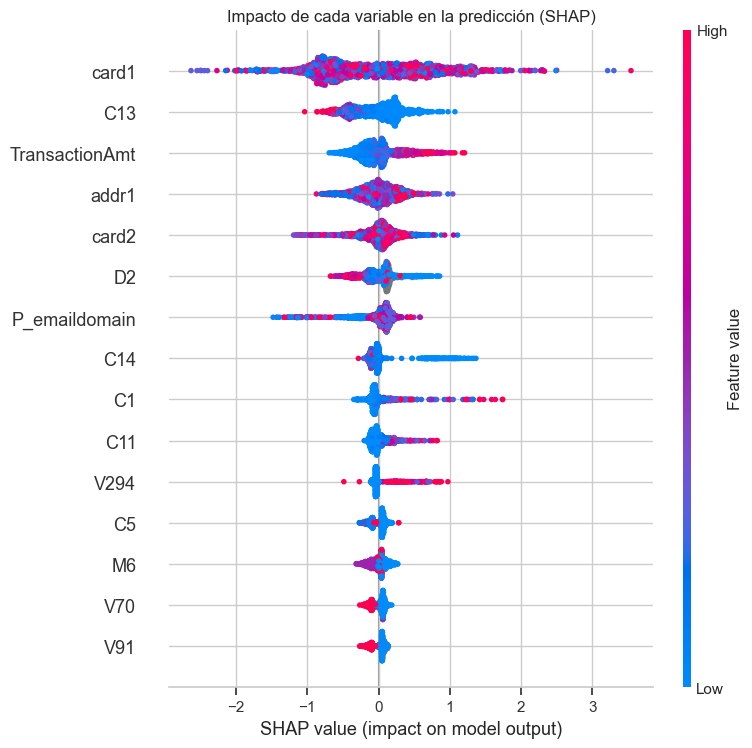

In [14]:
import warnings

import shap

muestra_shap = X_test.sample(n=2000, random_state=42)
X_shap = pipeline.named_steps["preprocesamiento"].transform(muestra_shap)

explicador = shap.TreeExplainer(pipeline.named_steps["modelo"])
with warnings.catch_warnings():
    # Aviso informativo de shap sobre el formato de salida con LightGBM; el resultado es un array (n, features)
    warnings.filterwarnings("ignore", message="LightGBM binary classifier")
    valores_shap = explicador.shap_values(X_shap)

shap.summary_plot(valores_shap, X_shap, max_display=15, show=False)
plt.title("Impacto de cada variable en la predicción (SHAP)")
plt.savefig(CARPETA_FIGURAS / "shap_summary.png", dpi=200, bbox_inches="tight")
plt.show()

## 11. ROI estimado

Estimamos el retorno usando las predicciones reales sobre test (~30 días de transacciones), con un modelo simple:

- **Beneficio**: el monto de los fraudes detectados. Suponemos que se recupera el 100%: es un supuesto optimista, porque en la práctica parte del dinero puede haberse movido antes de bloquear la tarjeta.
- **Costo**: revisar cada alerta, sea fraude real o falsa alarma. Los tres escenarios solo cambian cuánto cuesta esa revisión.

ROI = (beneficio − costo) / costo, mensual.

**Punto de equilibrio**: dividiendo el beneficio por la cantidad de alertas obtenemos cuánto fraude evita cada alerta en promedio. Mientras revisar una alerta cueste menos que eso, el modelo es rentable.

Los supuestos son ilustrativos, no datos de un banco real. Además, el dataset es una muestra de las transacciones de Vesta, no su volumen completo.

In [15]:
DIAS_POR_MES = 30

dias_test = df.loc[es_test, "dia_relativo"].nunique()
factor_mensual = DIAS_POR_MES / dias_test

montos_test = X_test["TransactionAmt"].to_numpy()
es_fraude = y_test.to_numpy() == 1
fraude_detectado = es_fraude & (pred_test == 1)

monto_fraude_total = montos_test[es_fraude].sum()
beneficio = montos_test[fraude_detectado].sum() * factor_mensual
alertas = pred_test.sum() * factor_mensual
equilibrio_por_alerta = beneficio / alertas

print(f"Período de test: {dias_test} días")
print(f"Fraude detectado: USD {beneficio:,.0f} por mes ({beneficio / factor_mensual / monto_fraude_total:.1%} del monto total en fraudes)")
print(f"Alertas: {alertas:,.0f} por mes")
print(f"Punto de equilibrio: USD {equilibrio_por_alerta:.1f} de fraude evitado por alerta")
print()

COSTO_POR_ALERTA = {"Pesimista": 10, "Base": 5, "Optimista": 3}

filas = []
for escenario, costo_por_alerta in COSTO_POR_ALERTA.items():
    costo = alertas * costo_por_alerta
    filas.append({
        "Escenario": escenario,
        "Costo por alerta (USD)": costo_por_alerta,
        "Costo mensual (USD)": round(costo),
        "Ganancia neta mensual (USD)": round(beneficio - costo),
        "ROI": f"{(beneficio - costo) / costo:.1f}x",
    })

tabla_roi = pd.DataFrame(filas).set_index("Escenario")
print(tabla_roi.to_string())

Período de test: 30 días
Fraude detectado: USD 144,270 por mes (31.5% del monto total en fraudes)
Alertas: 1,987 por mes
Punto de equilibrio: USD 72.6 de fraude evitado por alerta

           Costo por alerta (USD)  Costo mensual (USD)  Ganancia neta mensual (USD)    ROI
Escenario                                                                                 
Pesimista                      10                19870                       124400   6.3x
Base                            5                 9935                       134336  13.5x
Optimista                       3                 5961                       138310  23.2x


## 12. Guardado del modelo y datos de muestra

`model.pkl` guarda el pipeline completo (preprocesamiento + LightGBM) junto con el umbral de decisión y la lista de columnas de entrada. Así la app solo necesita cargarlo y pasarle transacciones crudas.

`datos_muestra.csv` tiene 100 transacciones del período de **test** (nunca vistas en el entrenamiento), con sus columnas originales. Incluimos 20 fraudes y 80 legítimas para que la demo muestre ambos casos. Por eso la muestra **no** respeta la proporción real de 3.5% de fraude.

In [16]:
import joblib

artefacto = {
    "pipeline": pipeline,
    "umbral": float(mejor_umbral),
    "columnas_entrada": COLUMNAS_ENTRADA,
}
joblib.dump(artefacto, "../model.pkl")
print("Modelo guardado en ../model.pkl")

transacciones_test = df.loc[es_test, ["TransactionID", "isFraud"] + COLUMNAS_ENTRADA]
fraudes = transacciones_test[transacciones_test["isFraud"] == 1].sample(n=20, random_state=42)
legitimas = transacciones_test[transacciones_test["isFraud"] == 0].sample(n=80, random_state=42)
muestra = pd.concat([fraudes, legitimas]).sample(frac=1, random_state=42)
muestra.to_csv("../datos_muestra.csv", index=False)
print(f"Muestra guardada en ../datos_muestra.csv: {muestra.shape}")

Modelo guardado en ../model.pkl


Muestra guardada en ../datos_muestra.csv: (100, 394)


## 13. Carga del modelo e inferencia

Cargamos `model.pkl` desde disco, como lo hace la app, y predecimos sobre `datos_muestra.csv` leído desde el CSV. Ninguna variable de este notebook interviene: solo el archivo guardado.

In [17]:
modelo_cargado = joblib.load("../model.pkl")
datos_nuevos = pd.read_csv("../datos_muestra.csv")

probabilidades = modelo_cargado["pipeline"].predict_proba(datos_nuevos[modelo_cargado["columnas_entrada"]])[:, 1]
resultado = datos_nuevos[["TransactionID", "TransactionAmt", "ProductCD", "isFraud"]].copy()
resultado["prob_fraude"] = probabilidades.round(3)
resultado["alerta"] = probabilidades >= modelo_cargado["umbral"]

print(f"Umbral cargado: {modelo_cargado['umbral']:.3f}")
print(f"Alertas: {resultado['alerta'].sum()} de {len(resultado)} | fraudes reales detectados: "
      f"{(resultado['alerta'] & (resultado['isFraud'] == 1)).sum()} de {(resultado['isFraud'] == 1).sum()}")
resultado.sort_values("prob_fraude", ascending=False).head(10)

Umbral cargado: 0.286
Alertas: 8 de 100 | fraudes reales detectados: 6 de 20


,TransactionID,TransactionAmt,ProductCD,isFraud,prob_fraude,alerta
54,3565743,30.000,S,1,0.998,True
9,3562111,96.524,C,1,0.897,True
97,3518336,600.000,R,1,0.880,True
25,3575582,186.000,W,1,0.614,True
59,3505485,554.000,W,0,0.548,True
35,3497140,69.595,C,1,0.467,True
27,3502882,76.604,C,0,0.438,True
56,3508731,28.035,C,1,0.390,True
45,3495892,32.277,C,1,0.263,False
30,3533639,64.309,C,1,0.194,False


## 14. Conclusiones y próximos pasos

**Conclusiones**

- El dataset tiene señal real: variables como `ProductCD`, el tipo de tarjeta y la falta de ciertos datos se relacionan claramente con el fraude.
- En test, el modelo alcanza ROC-AUC 0.89 y PR-AUC 0.53 (contra 0.035 de un modelo al azar). Detecta el 44% de los fraudes, y el 66% de sus alertas son fraudes reales.
- En monto detecta menos: el 31.5% de los dólares defraudados. Atrapa mejor los fraudes chicos que los grandes.
- Según SHAP, las variables que más pesan son `card1`, `C13`, `TransactionAmt` y `addr1`, y los montos altos empujan la predicción hacia fraude. Que `card1` (un identificador de la tarjeta) esté primera confirma que el modelo se apoya en reconocer tarjetas conocidas, lo mismo que vimos al comparar splits.
- Cada alerta evita en promedio unos USD 72.6 de fraude: el modelo es rentable mientras revisar una alerta cueste menos que eso. Con costos de revisión de USD 10, 5 y 3, el ROI mensual es de 6.3x, 13.5x y 23.2x.
- El split temporal es clave: con un split aleatorio las métricas salen mucho más altas, pero no reflejan cómo funcionaría el modelo con transacciones futuras.

**Próximos pasos**

1. Comparar con regresión logística, Random Forest y XGBoost usando el mismo split.
2. Optimizar hiperparámetros con `RandomizedSearchCV`.
3. Validar con varios cortes temporales (`TimeSeriesSplit`).
4. Agregar variables históricas por cliente (gasto promedio, transacciones previas).
5. Incorporar la tabla `identity`.
6. Elegir el umbral según el costo de cada tipo de error, dando más peso a los fraudes de monto alto.